In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/0664.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/1269.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/3863.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/2193.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/0733.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/3750.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/2008.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/2081.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/0106.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/0375.jpg


In [2]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score
)

from tqdm.auto import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [4]:
SEEDS = [42, 123, 999, 2025, 777]

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [11]:
NUM_EPOCHS = 10

BATCH_SIZE = 32

LEARNING_RATE = 1e-4

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdullahhasansajjad/lunghist700")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images
Path to dataset files: /kaggle/input/datasets/abdullahhasansajjad/lunghist700


In [6]:
TRAIN_DIR = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

TEST_DIR = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700"

In [7]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [12]:
full_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

external_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_transform
)

print("Training Classes :", full_dataset.classes)
print("External Classes :", external_dataset.classes)

print("Training Images :", len(full_dataset))
print("External Images :", len(external_dataset))

Training Classes : ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
External Classes : ['LungHist700_combined']
Training Images : 15000
External Images : 691


In [13]:
train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, internal_test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(len(train_dataset))
print(len(val_dataset))
print(len(internal_test_dataset))

10500
2250
2250


In [14]:
external_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_transform
)

print(external_dataset.classes)
print(len(external_dataset))

['LungHist700_combined']
691


In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

external_test_loader = DataLoader(
    external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [16]:
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=16):

        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))

        attention = self.sigmoid(avg_out + max_out)

        return x * attention

In [17]:
class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):

        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg = torch.mean(x, dim=1, keepdim=True)

        mx, _ = torch.max(x, dim=1, keepdim=True)

        attention = self.sigmoid(
            self.conv(
                torch.cat([avg, mx], dim=1)
            )
        )

        return x * attention

In [18]:
x = torch.randn(4,768,7,7)

ca = ChannelAttention(768)

sa = SpatialAttention()

print(ca(x).shape)

print(sa(x).shape)

torch.Size([4, 768, 7, 7])
torch.Size([4, 768, 7, 7])


In [19]:
class MSDGAF(nn.Module):

    def __init__(self, channels):

        super().__init__()

        # -----------------------------------
        # Multi-scale feature extractor
        # -----------------------------------

        self.dw3 = nn.Conv2d(
            channels * 2,
            channels * 2,
            kernel_size=3,
            padding=1,
            groups=channels * 2,
            bias=False
        )

        self.dw5 = nn.Conv2d(
            channels * 2,
            channels * 2,
            kernel_size=5,
            padding=2,
            groups=channels * 2,
            bias=False
        )

        self.pointwise = nn.Sequential(

            nn.Conv2d(
                channels * 4,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.GELU()
        )

        # -----------------------------------
        # Dynamic Gate
        # -----------------------------------

        self.gate = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.Sigmoid()

        )

        # -----------------------------------
        # Residual Refinement
        # -----------------------------------

        self.refine = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.GELU()

        )

    def forward(self, conv_feat, swin_feat):

        # concatenate

        fusion = torch.cat(
            [conv_feat, swin_feat],
            dim=1
        )

        # multi-scale

        feat3 = self.dw3(fusion)

        feat5 = self.dw5(fusion)

        fusion = torch.cat(
            [feat3, feat5],
            dim=1
        )

        fusion = self.pointwise(fusion)

        # dynamic gate

        gate = self.gate(fusion)

        fused = (
            gate * conv_feat
            +
            (1 - gate) * swin_feat
        )

        # residual fusion

        fused = fused + conv_feat + swin_feat

        fused = self.refine(fused)

        return fused

In [20]:
x1 = torch.randn(2,768,7,7)

x2 = torch.randn(2,768,7,7)

fusion = MSDGAF(768)

y = fusion(x1,x2)

print(y.shape)

torch.Size([2, 768, 7, 7])


In [21]:
import torch
import torch.nn as nn

class CGMSDGAF(nn.Module):

    def __init__(self, channels):

        super().__init__()

        # ---------- Cross Gate ----------

        self.conv_gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 16, 1, bias=False),
            nn.GELU(),
            nn.Conv2d(channels // 16, channels, 1, bias=False),
            nn.Sigmoid()
        )

        self.swin_gate = nn.Sequential(
            nn.Conv2d(channels, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

        # ---------- Multi-scale ----------

        self.dw3 = nn.Conv2d(
            channels * 2,
            channels * 2,
            kernel_size=3,
            padding=1,
            groups=channels * 2,
            bias=False
        )

        self.dw5 = nn.Conv2d(
            channels * 2,
            channels * 2,
            kernel_size=5,
            padding=2,
            groups=channels * 2,
            bias=False
        )

        self.project = nn.Sequential(

            nn.Conv2d(
                channels * 4,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.GELU()

        )

        # ---------- Refinement ----------

        self.refine = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(channels),

            nn.GELU()

        )

    def forward(self, conv_feat, swin_feat):

        # ---------------------------------
        # Cross Guidance
        # ---------------------------------

        channel_gate = self.conv_gate(conv_feat)

        spatial_gate = self.swin_gate(swin_feat)

        guided_swin = swin_feat * channel_gate

        guided_conv = conv_feat * spatial_gate

        # ---------------------------------
        # Feature Fusion
        # ---------------------------------

        fusion = torch.cat(
            [guided_conv, guided_swin],
            dim=1
        )

        multi3 = self.dw3(fusion)

        multi5 = self.dw5(fusion)

        fusion = torch.cat(
            [multi3, multi5],
            dim=1
        )

        fusion = self.project(fusion)

        # ---------------------------------
        # Residual
        # ---------------------------------

        fusion = fusion + guided_conv + guided_swin

        fusion = self.refine(fusion)

        return fusion

In [22]:
x1 = torch.randn(4,768,7,7)

x2 = torch.randn(4,768,7,7)

module = CGMSDGAF(768)

y = module(x1,x2)

print(y.shape)

torch.Size([4, 768, 7, 7])


In [23]:
class FeatureAlignment(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.align = nn.Sequential(

            nn.Conv2d(channels, channels, 1, bias=False),

            nn.BatchNorm2d(channels),

            nn.GELU()

        )

    def forward(self, x):

        return self.align(x)

In [24]:
class ClassificationHead(nn.Module):

    def __init__(self, channels=768, hidden=256, num_classes=3):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(channels, hidden)

        self.relu = nn.ReLU(inplace=True)

        self.dropout = nn.Dropout(0.4)

        self.fc2 = nn.Linear(hidden, num_classes)

    def forward(self, x, return_features=False):

        x = self.pool(x)

        x = self.flatten(x)

        features = self.fc1(x)

        features = self.relu(features)

        features = self.dropout(features)

        logits = self.fc2(features)

        if return_features:
            return logits, features

        return logits

In [25]:
class ConvNeXtSwinCGMSDGAF(nn.Module):

    def __init__(self, num_classes=3):

        super().__init__()

        self.convnext = ConvNeXtBackbone()

        self.swin = SwinBackbone()

        self.align_conv = FeatureAlignment(768)

        self.align_swin = FeatureAlignment(768)

        self.ca = ChannelAttention(768)

        self.sa = SpatialAttention()

        self.fusion = CGMSDGAF(768)

        self.head = ClassificationHead(
            channels=768,
            hidden=256,
            num_classes=num_classes
        )

    def forward(self, x):

        conv = self.convnext(x)

        swin = self.swin(x)

        conv = self.align_conv(conv)

        swin = self.align_swin(swin)

        conv = self.ca(conv)

        swin = self.sa(swin)

        fused = self.fusion(conv, swin)

        return self.head(fused)

    def extract_features(self, x):

        conv = self.convnext(x)

        swin = self.swin(x)

        conv = self.align_conv(conv)

        swin = self.align_swin(swin)

        conv = self.ca(conv)

        swin = self.sa(swin)

        fused = self.fusion(conv, swin)

        _, features = self.head(fused, return_features=True)

        return features

In [26]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torch.nn as nn

class ConvNeXtBackbone(nn.Module):

    def __init__(self):
        super().__init__()

        model = convnext_tiny(
            weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )

        # Keep only the feature extractor
        self.features = model.features

    def forward(self, x):

        x = self.features(x)

        # Output shape: [B, 768, 7, 7]
        return x

In [27]:
from torchvision.models import swin_t, Swin_T_Weights
import torch.nn as nn

class SwinBackbone(nn.Module):

    def __init__(self):
        super().__init__()

        model = swin_t(
            weights=Swin_T_Weights.IMAGENET1K_V1
        )

        # Feature extractor only
        self.features = model.features

    def forward(self, x):

        x = self.features(x)

        # TorchVision Swin outputs NHWC
        # Convert to NCHW
        x = x.permute(0, 3, 1, 2).contiguous()

        return x

In [28]:
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights,
    swin_t,
    Swin_T_Weights
)

conv = convnext_tiny(
    weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1
)

swin = swin_t(
    weights=Swin_T_Weights.IMAGENET1K_V1
)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 202MB/s] 


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 217MB/s] 


In [29]:
def forward(self, x):

    conv = self.convnext(x)
    print("ConvNeXt:", conv.shape)

    swin = self.swin(x)
    print("Swin:", swin.shape)

    conv = self.align_conv(conv)
    print("Aligned Conv:", conv.shape)

    swin = self.align_swin(swin)
    print("Aligned Swin:", swin.shape)

    conv = self.ca(conv)
    print("Channel Attention:", conv.shape)

    swin = self.sa(swin)
    print("Spatial Attention:", swin.shape)

    fused = self.fusion(conv, swin)
    print("Fusion:", fused.shape)

    out = self.head(fused)
    print("Output:", out.shape)

    return self.head(fused)

In [30]:
conv = ConvNeXtBackbone().to(device)
swin = SwinBackbone().to(device)

x = torch.randn(2,3,224,224).to(device)

print("Conv:", conv(x).shape)
print("Swin:", swin(x).shape)

Conv: torch.Size([2, 768, 7, 7])
Swin: torch.Size([2, 768, 7, 7])


In [31]:
model = ConvNeXtSwinCGMSDGAF(num_classes=3).to(device)

In [32]:
model = ConvNeXtSwinCGMSDGAF(num_classes=3).to(device)

dummy = torch.randn(2,3,224,224).to(device)

out = model(dummy)

print(out.shape)

torch.Size([2, 3])


In [33]:
def forward(self, x):

    conv = self.convnext(x)
    print("ConvNeXt:", conv.shape)

    swin = self.swin(x)
    print("Swin:", swin.shape)

    conv = self.align_conv(conv)
    print("Aligned Conv:", conv.shape)

    swin = self.align_swin(swin)
    print("Aligned Swin:", swin.shape)

    conv = self.ca(conv)
    print("Channel Attention:", conv.shape)

    swin = self.sa(swin)
    print("Spatial Attention:", swin.shape)

    fused = self.fusion(conv, swin)
    print("Fusion:", fused.shape)

    out = self.head(fused)
    print("Output:", out.shape)

    return out

In [34]:
print(model)

ConvNeXtSwinCGMSDGAF(
  (convnext): ConvNeXtBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2

In [35]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [36]:
def get_optimizer(model):

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    return optimizer

In [37]:
def get_scheduler(optimizer):

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )

    return scheduler

In [38]:
scaler = torch.amp.GradScaler("cuda")


In [39]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

In [40]:
def create_model():

    model = ConvNeXtSwinCGMSDGAF(
        num_classes=3
    ).to(device)

    return model

In [41]:
results = []

for seed in SEEDS:

    print("="*70)
    print(f"Training with Seed : {seed}")
    print("="*70)

    set_seed(seed)

    model = create_model()

    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )

    optimizer = get_optimizer(model)

    scheduler = get_scheduler(optimizer)

    best_acc = 0.0

Training with Seed : 42
Training with Seed : 123
Training with Seed : 999
Training with Seed : 2025
Training with Seed : 777


In [42]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0

    preds = []
    labels_list = []

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        pred = outputs.argmax(1)

        preds.extend(pred.cpu().numpy())

        labels_list.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    epoch_acc = accuracy_score(labels_list, preds)

    return epoch_loss, epoch_acc

In [43]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    preds = []
    labels_list = []
    probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_loss += loss.item()

            pred = outputs.argmax(1)

            prob = torch.softmax(outputs,1)

            preds.extend(pred.cpu().numpy())

            probs.extend(prob.cpu().numpy())

            labels_list.extend(labels.cpu().numpy())

    return {

        "loss": running_loss/len(loader),

        "acc": accuracy_score(labels_list,preds),

        "precision": precision_score(labels_list,preds,average="macro"),

        "recall": recall_score(labels_list,preds,average="macro"),

        "f1": f1_score(labels_list,preds,average="macro"),

        "auc": roc_auc_score(
            labels_list,
            np.array(probs),
            multi_class="ovr"
        )

    }

In [44]:
NUM_EPOCHS = 10

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import numpy as np
import torch


def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_loss += loss.item()

            # ---------- Prediction ----------
            preds = outputs.argmax(dim=1)

            # ---------- Probability ----------
            probs = torch.softmax(outputs.float(), dim=1)

            all_labels.extend(labels.cpu().numpy())

            all_preds.extend(preds.cpu().numpy())

            all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / len(loader)

    all_probs = np.asarray(all_probs, dtype=np.float32)

    # Numerical stability
    all_probs = np.clip(all_probs, 1e-7, 1.0)

    all_probs = all_probs / all_probs.sum(axis=1, keepdims=True)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    # Safe ROC-AUC
    try:

        auc = roc_auc_score(
            all_labels,
            all_probs,
            multi_class="ovr",
            average="macro"
        )

    except ValueError:

        auc = float("nan")

    return {

        "loss": avg_loss,

        "acc": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "auc": auc,

        "labels": all_labels,

        "preds": all_preds,

        "probs": all_probs

    }

In [46]:
def freeze_backbones(model):

    for param in model.convnext.parameters():
        param.requires_grad = False

    for param in model.swin.parameters():
        param.requires_grad = False

    print("Backbones Frozen")

In [47]:
def unfreeze_backbones(model):

    for param in model.convnext.parameters():
        param.requires_grad = True

    for param in model.swin.parameters():
        param.requires_grad = True

    print("Backbones Unfrozen")

In [48]:
import numpy as np

class EarlyStopping:

    def __init__(
        self,
        patience=7,
        delta=0,
        path="best_model.pth"
    ):

        self.patience = patience
        self.delta = delta
        self.path = path

        self.counter = 0
        self.best_score = None

        self.early_stop = False

    def __call__(self, score, model):

        if self.best_score is None:

            self.best_score = score

            torch.save(model.state_dict(), self.path)

        elif score < self.best_score + self.delta:

            self.counter += 1

            print(
                f"EarlyStopping {self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

        else:

            self.best_score = score

            self.counter = 0

            torch.save(model.state_dict(), self.path)

In [49]:
freeze_backbones(model)

optimizer = torch.optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-3,

    weight_decay=1e-4

)

Backbones Frozen


In [50]:
best_acc=0

patience=5

counter=0

history={

    "train_loss":[],

    "val_loss":[],

    "train_acc":[],

    "val_acc":[]

}

In [51]:
train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    scaler,
    device
)

metrics = validate(
    model,
    val_loader,
    criterion,
    device
)

val_loss = metrics["loss"]
val_acc = metrics["acc"]

In [52]:
results = []

for seed in SEEDS:

    print("="*80)
    print(f"Training with Seed: {seed}")
    print("="*80)

    set_seed(seed)

    # Fresh model
    model = create_model()

    freeze_backbones(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda")

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_acc = 0
    counter = 0
    patience = 7

    EPOCHS = 10

    best_model_path = f"best_seed_{seed}.pth"

    # ==========================
    # YOUR EXISTING EPOCH LOOP
    # ==========================

    for epoch in range(EPOCHS):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler,
            device
        )

        metrics = validate(
            model,
            val_loader,
            criterion,
            device
        )

        val_loss = metrics["loss"]
        val_acc = metrics["acc"]

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Seed {seed} | "
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_acc:

            best_acc = val_acc
            counter = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )

            print("✅ Best model saved!")

        else:

            counter += 1

            print(
                f"EarlyStopping Counter: {counter}/{patience}"
            )

            if counter >= patience:

                print("🛑 Early stopping triggered.")
                break

    # ==========================
    # LOAD BEST MODEL
    # ==========================

    model.load_state_dict(
        torch.load(best_model_path)
    )

    # --------------------------
    # Evaluate on LungHist700
    # --------------------------
    # test_metrics = test_model(...)

    # results.append(test_metrics)

Training with Seed: 42
Backbones Frozen
Seed 42 | Epoch 01/10 | Train Loss: 0.4108 | Train Acc: 0.9426 | Val Loss: 0.3468 | Val Acc: 0.9729
✅ Best model saved!
Seed 42 | Epoch 02/10 | Train Loss: 0.3693 | Train Acc: 0.9625 | Val Loss: 0.3288 | Val Acc: 0.9804
✅ Best model saved!
Seed 42 | Epoch 03/10 | Train Loss: 0.3519 | Train Acc: 0.9721 | Val Loss: 0.3423 | Val Acc: 0.9782
EarlyStopping Counter: 1/7
Seed 42 | Epoch 04/10 | Train Loss: 0.3407 | Train Acc: 0.9776 | Val Loss: 0.3060 | Val Acc: 0.9951
✅ Best model saved!
Seed 42 | Epoch 05/10 | Train Loss: 0.3293 | Train Acc: 0.9825 | Val Loss: 0.3064 | Val Acc: 0.9924
EarlyStopping Counter: 1/7
Seed 42 | Epoch 07/10 | Train Loss: 0.3128 | Train Acc: 0.9929 | Val Loss: 0.2965 | Val Acc: 0.9982
✅ Best model saved!
Seed 42 | Epoch 08/10 | Train Loss: 0.3087 | Train Acc: 0.9929 | Val Loss: 0.2958 | Val Acc: 0.9978
EarlyStopping Counter: 1/7
Seed 42 | Epoch 09/10 | Train Loss: 0.3063 | Train Acc: 0.9955 | Val Loss: 0.2945 | Val Acc: 0.9991

In [59]:
best_model_path = f"best_model_seed_{seed}.pth"

# Whenever validation accuracy improves
if val_acc > best_acc:
    best_acc = val_acc

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_acc": best_acc,
        "seed": seed
    }, best_model_path)

    print(f"Saved best model for seed {seed}")

In [60]:
import os
import glob

model_paths = sorted(glob.glob("/kaggle/working/best_seed_*.pth"))

print(model_paths)

['/kaggle/working/best_seed_123.pth', '/kaggle/working/best_seed_2025.pth', '/kaggle/working/best_seed_42.pth', '/kaggle/working/best_seed_777.pth', '/kaggle/working/best_seed_999.pth']


In [52]:
import os
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    cohen_kappa_score
)

results = []

for model_path in model_paths:

    # Load checkpoint
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print(f"\nEvaluating {os.path.basename(model_path)}")

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in internal_test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # In case model returns multiple outputs
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = torch.max(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"Accuracy            : {acc*100:.2f}%")
    print(f"Balanced Accuracy   : {bal_acc*100:.2f}%")
    print(f"Precision           : {precision*100:.2f}%")
    print(f"Recall              : {recall*100:.2f}%")
    print(f"F1-score            : {f1*100:.2f}%")
    print(f"MCC                 : {mcc:.4f}")
    print(f"Cohen's Kappa       : {kappa:.4f}")

    results.append({
        "Seed": os.path.basename(model_path),
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "MCC": mcc,
        "Kappa": kappa
    })

# =====================================================
# Per-seed Results
# =====================================================

df = pd.DataFrame(results)

print("\nPer-seed Results:")
display(df)

# =====================================================
# Mean ± SD
# =====================================================

summary = pd.DataFrame(index=df.columns[1:])

summary["Mean"] = df.iloc[:, 1:].mean()
summary["Std"] = df.iloc[:, 1:].std()

summary["Mean ± SD"] = summary.apply(
    lambda x: f"{x['Mean']*100:.2f} ± {x['Std']*100:.2f}"
    if x.name not in ["MCC", "Kappa"]
    else f"{x['Mean']:.4f} ± {x['Std']:.4f}",
    axis=1
)

print("\nMean ± SD Across 5 Seeds:")
display(summary)


Evaluating best_seed_123.pth
Accuracy            : 99.96%
Balanced Accuracy   : 99.96%
Precision           : 99.96%
Recall              : 99.96%
F1-score            : 99.96%
MCC                 : 0.9993
Cohen's Kappa       : 0.9993

Evaluating best_seed_2025.pth
Accuracy            : 99.87%
Balanced Accuracy   : 99.87%
Precision           : 99.87%
Recall              : 99.87%
F1-score            : 99.87%
MCC                 : 0.9980
Cohen's Kappa       : 0.9980

Evaluating best_seed_42.pth
Accuracy            : 99.91%
Balanced Accuracy   : 99.92%
Precision           : 99.91%
Recall              : 99.91%
F1-score            : 99.91%
MCC                 : 0.9987
Cohen's Kappa       : 0.9987

Evaluating best_seed_777.pth
Accuracy            : 99.82%
Balanced Accuracy   : 99.83%
Precision           : 99.82%
Recall              : 99.82%
F1-score            : 99.82%
MCC                 : 0.9973
Cohen's Kappa       : 0.9973

Evaluating best_seed_999.pth
Accuracy            : 99.82%
Balanced 

,Seed,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Kappa
0,best_seed_123.pth,0.999556,0.999577,0.999556,0.999556,0.999556,0.999333,0.999333
1,best_seed_2025.pth,0.998667,0.998700,0.998667,0.998667,0.998667,0.997999,0.997999
2,best_seed_42.pth,0.999111,0.999154,0.999114,0.999111,0.999111,0.998667,0.998666
3,best_seed_777.pth,0.998222,0.998308,0.998232,0.998222,0.998222,0.997337,0.997332
4,best_seed_999.pth,0.998222,0.998277,0.998225,0.998222,0.998222,0.997333,0.997332



Mean ± SD Across 5 Seeds:


,Mean,Std,Mean ± SD
Accuracy,0.998756,0.000579,99.88 ± 0.06
Balanced Accuracy,0.998803,0.000560,99.88 ± 0.06
Precision,0.998759,0.000577,99.88 ± 0.06
Recall,0.998756,0.000579,99.88 ± 0.06
F1-score,0.998756,0.000579,99.88 ± 0.06
MCC,0.998134,0.000869,0.9981 ± 0.0009
Kappa,0.998132,0.000870,0.9981 ± 0.0009


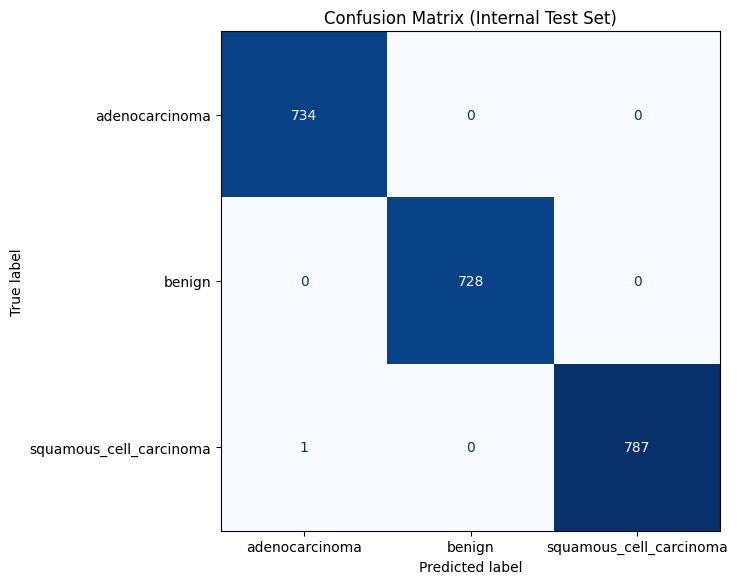

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -------------------------
# Load Best Model
# -------------------------
best_model = model_paths[0]      # Change index if another seed performed best

model.load_state_dict(torch.load(best_model, map_location=device))
model.to(device)
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in internal_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        if isinstance(outputs, tuple):
            outputs = outputs[0]

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# -------------------------
# Confusion Matrix
# -------------------------

class_names = internal_test_dataset.dataset.classes

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix (Internal Test Set)")
plt.tight_layout()

plt.savefig(
    "confusion_matrix_internal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

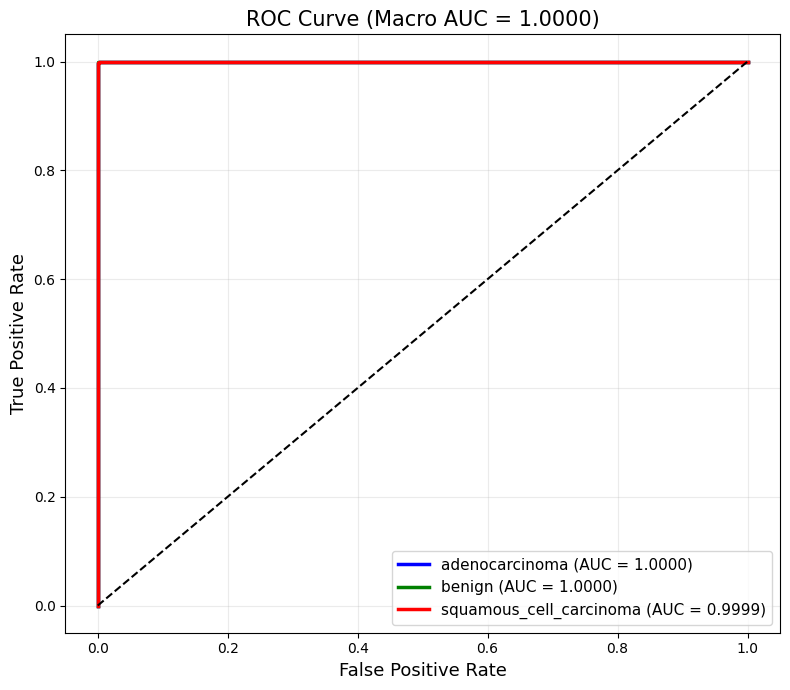


Macro AUC : 1.0000
adenocarcinoma : 1.0000
benign : 1.0000
squamous_cell_carcinoma : 0.9999


In [54]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)

# ----------------------------------------------------
# Load Best Checkpoint
# ----------------------------------------------------

best_model = model_paths[0]   # Change if another seed is your best

model.load_state_dict(torch.load(best_model, map_location=device))
model.to(device)
model.eval()

# ----------------------------------------------------
# Predictions
# ----------------------------------------------------

y_true = []
y_score = []

with torch.no_grad():

    for images, labels in internal_test_loader:

        images = images.to(device)

        outputs = model(images)

        if isinstance(outputs, tuple):
            outputs = outputs[0]

        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_score = np.array(y_score)

# ----------------------------------------------------
# Class Names
# ----------------------------------------------------

class_names = internal_test_dataset.dataset.classes

n_classes = len(class_names)

# ----------------------------------------------------
# Binarize Labels
# ----------------------------------------------------

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

# ----------------------------------------------------
# ROC Curves
# ----------------------------------------------------

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# ----------------------------------------------------
# Macro AUC
# ----------------------------------------------------

macro_auc = roc_auc_score(
    y_true_bin,
    y_score,
    average="macro",
    multi_class="ovr"
)

# ----------------------------------------------------
# Plot
# ----------------------------------------------------

plt.figure(figsize=(8,7))

colors = ["blue","green","red"]

for i, color in zip(range(n_classes), colors):

    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2.5,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13
)

plt.title(
    f"ROC Curve (Macro AUC = {macro_auc:.4f})",
    fontsize=15
)

plt.legend(
    loc="lower right",
    fontsize=11
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "ROC_Internal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nMacro AUC : {macro_auc:.4f}")

for i in range(n_classes):
    print(f"{class_names[i]} : {roc_auc[i]:.4f}")

In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                         precision    recall  f1-score   support

         adenocarcinoma     0.9986    1.0000    0.9993       734
                 benign     1.0000    1.0000    1.0000       728
squamous_cell_carcinoma     1.0000    0.9987    0.9994       788

               accuracy                         0.9996      2250
              macro avg     0.9995    0.9996    0.9996      2250
           weighted avg     0.9996    0.9996    0.9996      2250



In [56]:
import glob
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    cohen_kappa_score
)

# -------------------------------------------------------
# Find all checkpoints
# -------------------------------------------------------

model_paths = sorted(
    glob.glob("/kaggle/working/best_seed_*.pth")
)

results = []

# -------------------------------------------------------
# Evaluate each seed
# -------------------------------------------------------

for model_path in model_paths:

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in external_test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    results.append({
        "Model": model_path.split("/")[-1],
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "MCC": mcc,
        "Kappa": kappa
    })

# -------------------------------------------------------
# Results Table
# -------------------------------------------------------

df = pd.DataFrame(results)

display(df)

# -------------------------------------------------------
# Mean ± SD
# -------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "MCC",
        "Kappa"
    ],
    "Mean ± SD": [
        f"{df['Accuracy'].mean()*100:.2f} ± {df['Accuracy'].std()*100:.2f}",
        f"{df['Balanced Accuracy'].mean()*100:.2f} ± {df['Balanced Accuracy'].std()*100:.2f}",
        f"{df['Precision'].mean()*100:.2f} ± {df['Precision'].std()*100:.2f}",
        f"{df['Recall'].mean()*100:.2f} ± {df['Recall'].std()*100:.2f}",
        f"{df['F1-score'].mean()*100:.2f} ± {df['F1-score'].std()*100:.2f}",
        f"{df['MCC'].mean():.4f} ± {df['MCC'].std():.4f}",
        f"{df['Kappa'].mean():.4f} ± {df['Kappa'].std():.4f}",
    ]
})

print("\nExternal Validation (LungHist700)")
display(summary)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Kappa
0,best_seed_123.pth,0.477569,0.477569,1.0,0.477569,0.646425,0.0,0.0
1,best_seed_2025.pth,0.457308,0.457308,1.0,0.457308,0.627607,0.0,0.0
2,best_seed_42.pth,0.484805,0.484805,1.0,0.484805,0.653021,0.0,0.0
3,best_seed_777.pth,0.507959,0.507959,1.0,0.507959,0.673704,0.0,0.0
4,best_seed_999.pth,0.451520,0.451520,1.0,0.451520,0.622134,0.0,0.0



External Validation (LungHist700)


,Metric,Mean ± SD
0,Accuracy,47.58 ± 2.26
1,Balanced Accuracy,47.58 ± 2.26
2,Precision,100.00 ± 0.00
3,Recall,47.58 ± 2.26
4,F1-score,64.46 ± 2.07
5,MCC,0.0000 ± 0.0000
6,Kappa,0.0000 ± 0.0000


In [57]:
import numpy as np

print("True labels:")
print(np.bincount(y_true))

print("Predicted labels:")
print(np.bincount(y_pred))

True labels:
[691]
Predicted labels:
[312  18 361]


In [58]:
EXTERNAL_DATASET_PATH = "/kaggle/input/LungHist700/LungHist700_combined/data/images"

In [59]:
transform = internal_test_loader.dataset.dataset.transform

In [60]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "aca" in dirs and "nor" in dirs and "ssc" in dirs:
        print(root)

/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images


In [61]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

EXTERNAL_DATASET_PATH = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

external_dataset = ImageFolder(
    root=EXTERNAL_DATASET_PATH,
    transform=internal_test_loader.dataset.dataset.transform
)

external_test_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(external_dataset.class_to_idx)
print(len(external_dataset))

{'aca': 0, 'nor': 1, 'ssc': 2}
691


In [62]:
from collections import Counter

labels = [label for _, label in external_dataset]
print(Counter(labels))

Counter({0: 280, 2: 260, 1: 151})


In [63]:
import glob
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    cohen_kappa_score
)

# -------------------------------------------------------
# Find all checkpoints
# -------------------------------------------------------

model_paths = sorted(
    glob.glob("/kaggle/working/best_seed_*.pth")
)

results = []

# -------------------------------------------------------
# Evaluate each seed
# -------------------------------------------------------

for model_path in model_paths:

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in external_test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    results.append({
        "Model": model_path.split("/")[-1],
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "MCC": mcc,
        "Kappa": kappa
    })

# -------------------------------------------------------
# Results Table
# -------------------------------------------------------

df = pd.DataFrame(results)

display(df)

# -------------------------------------------------------
# Mean ± SD
# -------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "MCC",
        "Kappa"
    ],
    "Mean ± SD": [
        f"{df['Accuracy'].mean()*100:.2f} ± {df['Accuracy'].std()*100:.2f}",
        f"{df['Balanced Accuracy'].mean()*100:.2f} ± {df['Balanced Accuracy'].std()*100:.2f}",
        f"{df['Precision'].mean()*100:.2f} ± {df['Precision'].std()*100:.2f}",
        f"{df['Recall'].mean()*100:.2f} ± {df['Recall'].std()*100:.2f}",
        f"{df['F1-score'].mean()*100:.2f} ± {df['F1-score'].std()*100:.2f}",
        f"{df['MCC'].mean():.4f} ± {df['MCC'].std():.4f}",
        f"{df['Kappa'].mean():.4f} ± {df['Kappa'].std():.4f}",
    ]
})

print("\nExternal Validation (LungHist700)")
display(summary)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Kappa
0,best_seed_123.pth,0.522431,0.466750,0.605715,0.522431,0.482934,0.242257,0.225526
1,best_seed_2025.pth,0.513748,0.451278,0.576224,0.513748,0.459562,0.229221,0.209694
2,best_seed_42.pth,0.518090,0.459843,0.617304,0.518090,0.470962,0.238578,0.217994
3,best_seed_777.pth,0.536903,0.473468,0.631489,0.536903,0.486440,0.267237,0.246941
4,best_seed_999.pth,0.535456,0.471342,0.637091,0.535456,0.478544,0.273841,0.245774



External Validation (LungHist700)


,Metric,Mean ± SD
0,Accuracy,52.53 ± 1.04
1,Balanced Accuracy,46.45 ± 0.91
2,Precision,61.36 ± 2.42
3,Recall,52.53 ± 1.04
4,F1-score,47.57 ± 1.07
5,MCC,0.2502 ± 0.0193
6,Kappa,0.2292 ± 0.0167


In [71]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

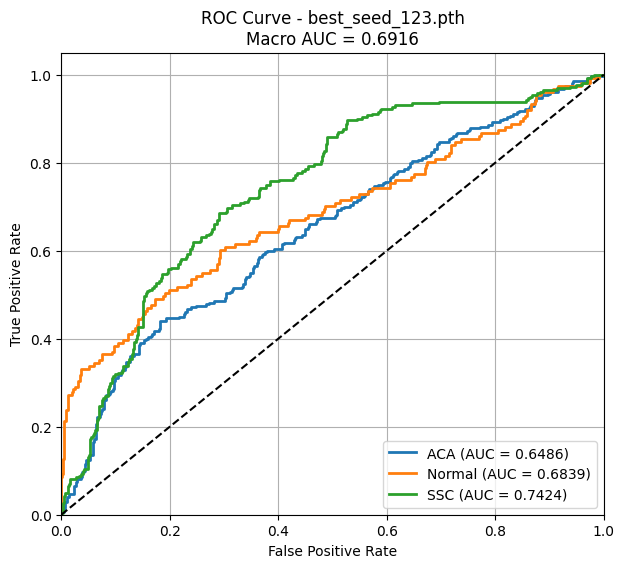

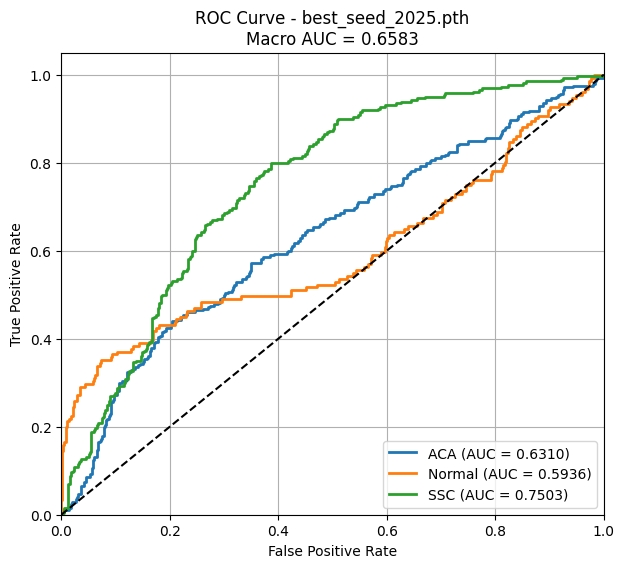

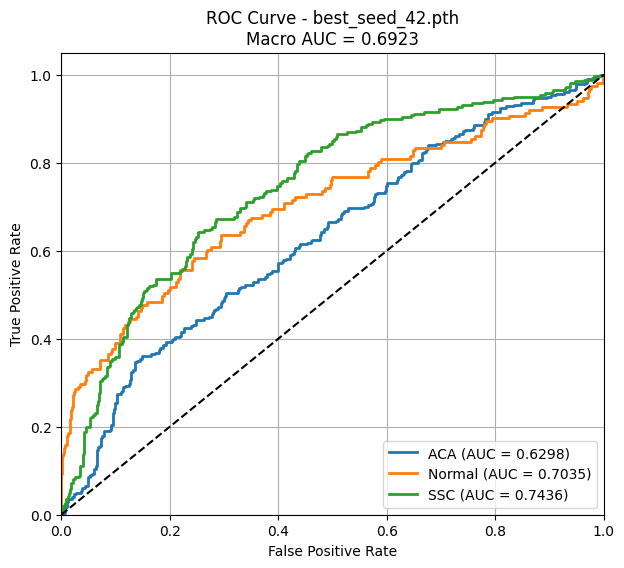

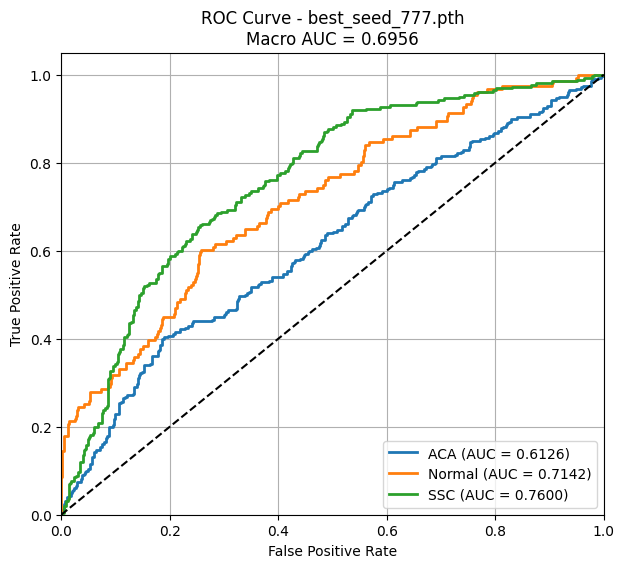

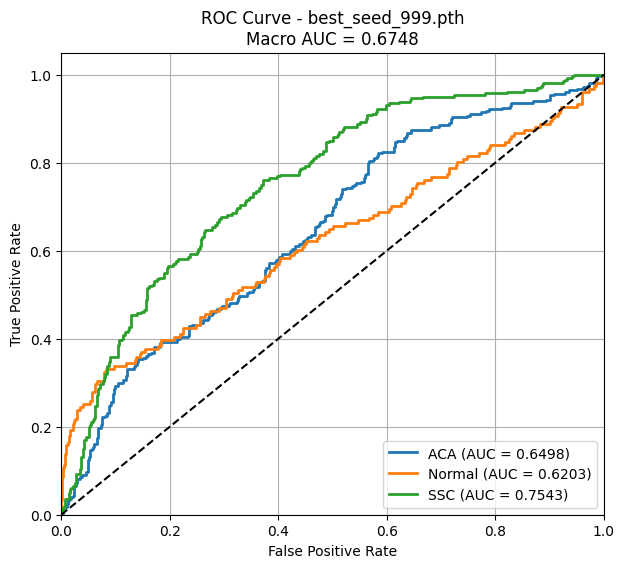

In [72]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import glob

model_paths = sorted(glob.glob("/kaggle/working/best_seed_*.pth"))

class_names = ["ACA", "Normal", "SSC"]

for model_path in model_paths:

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    y_true = []
    y_score = []

    with torch.no_grad():

        for images, labels in external_test_loader:

            images = images.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            probs = torch.softmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

    plt.figure(figsize=(7,6))

    auc_scores = []

    for i in range(3):

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{class_names[i]} (AUC = {roc_auc:.4f})"
        )

    plt.plot([0,1],[0,1],'k--')

    plt.xlim([0,1])
    plt.ylim([0,1.05])

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"ROC Curve - {model_path.split('/')[-1]}\n"
        f"Macro AUC = {np.mean(auc_scores):.4f}"
    )

    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [64]:
per_class_results = []

In [65]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

In [66]:
# -------------------------------------------------------
# Class-wise Precision, Recall, F1
# -------------------------------------------------------

p_cls, r_cls, f_cls, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    average=None,
    zero_division=0
)

class_names = ["ACA", "Normal", "SSC"]

for i, cls in enumerate(class_names):

    per_class_results.append({
        "Model": model_path.split("/")[-1],
        "Class": cls,
        "Precision": p_cls[i],
        "Recall": r_cls[i],
        "F1-score": f_cls[i],
        "Support": support[i]
    })

In [70]:
import glob
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    cohen_kappa_score
)

# -------------------------------------------------------
# Find all checkpoints
# -------------------------------------------------------

model_paths = sorted(
    glob.glob("/kaggle/working/best_seed_*.pth")
)

results = []
per_class_results = []

class_names = ["ACA", "Normal", "SSC"]

# -------------------------------------------------------
# Evaluate each seed
# -------------------------------------------------------

for model_path in model_paths:

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in external_test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # ---------------- Overall Metrics ----------------

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    results.append({
        "Seed": model_path.split("/")[-1],
        "Accuracy": acc * 100,
        "Balanced Accuracy": bal_acc * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1-score": f1 * 100,
        "MCC": mcc,
        "Kappa": kappa
    })

    # ---------------- Class-wise Metrics ----------------

    p_cls, r_cls, f_cls, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        average=None,
        zero_division=0
    )

    print(f"\n{'='*70}")
    print(model_path.split("/")[-1])
    print(f"{'='*70}")

    class_df = pd.DataFrame({
        "Class": class_names,
        "Precision": (p_cls * 100).round(2),
        "Recall": (r_cls * 100).round(2),
        "F1-score": (f_cls * 100).round(2),
        "Support": support
    })

    display(class_df)

    for i in range(3):
        per_class_results.append({
            "Seed": model_path.split("/")[-1],
            "Class": class_names[i],
            "Precision": p_cls[i] * 100,
            "Recall": r_cls[i] * 100,
            "F1-score": f_cls[i] * 100,
            "Support": support[i]
        })

# -------------------------------------------------------
# Overall Results
# -------------------------------------------------------

overall_df = pd.DataFrame(results)

print("\nOverall Results")
display(overall_df)

# -------------------------------------------------------
# Overall Mean ± SD
# -------------------------------------------------------

summary = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "MCC",
        "Kappa"
    ],
    "Mean ± SD":[
        f"{overall_df['Accuracy'].mean():.2f} ± {overall_df['Accuracy'].std():.2f}",
        f"{overall_df['Balanced Accuracy'].mean():.2f} ± {overall_df['Balanced Accuracy'].std():.2f}",
        f"{overall_df['Precision'].mean():.2f} ± {overall_df['Precision'].std():.2f}",
        f"{overall_df['Recall'].mean():.2f} ± {overall_df['Recall'].std():.2f}",
        f"{overall_df['F1-score'].mean():.2f} ± {overall_df['F1-score'].std():.2f}",
        f"{overall_df['MCC'].mean():.4f} ± {overall_df['MCC'].std():.4f}",
        f"{overall_df['Kappa'].mean():.4f} ± {overall_df['Kappa'].std():.4f}"
    ]
})

print("\nOverall Mean ± SD")
display(summary)

# -------------------------------------------------------
# Per-seed Class-wise Results
# -------------------------------------------------------

per_class_df = pd.DataFrame(per_class_results)

print("\nPer-seed Class-wise Results")
display(per_class_df)

# -------------------------------------------------------
# Class-wise Mean ± SD
# -------------------------------------------------------

class_summary = (
    per_class_df
    .groupby("Class")[["Precision", "Recall", "F1-score"]]
    .agg(["mean", "std"])
)

rows = []

for cls in class_names:

    rows.append({
        "Class": cls,
        "Precision": f"{class_summary.loc[cls, ('Precision','mean')]:.2f} ± {class_summary.loc[cls, ('Precision','std')]:.2f}",
        "Recall": f"{class_summary.loc[cls, ('Recall','mean')]:.2f} ± {class_summary.loc[cls, ('Recall','std')]:.2f}",
        "F1-score": f"{class_summary.loc[cls, ('F1-score','mean')]:.2f} ± {class_summary.loc[cls, ('F1-score','std')]:.2f}"
    })

class_summary_df = pd.DataFrame(rows)

print("\nClass-wise Mean ± SD")
display(class_summary_df)


best_seed_123.pth


,Class,Precision,Recall,F1-score,Support
0,ACA,52.19,51.07,51.62,280
1,Normal,100.00,11.92,21.30,151
2,SSC,52.13,80.00,63.13,260



best_seed_2025.pth


,Class,Precision,Recall,F1-score,Support
0,ACA,52.61,46.79,49.53,280
1,Normal,91.67,7.28,13.50,151
2,SSC,50.47,83.46,62.90,260



best_seed_42.pth


...

,Metric,Mean ± SD
0,Accuracy,51.98 ± 0.89
1,Balanced Accuracy,46.08 ± 1.00
2,Precision,61.41 ± 0.84
3,Recall,51.98 ± 0.89
4,F1-score,47.23 ± 1.22
5,MCC,0.2398 ± 0.0156
6,Kappa,0.2203 ± 0.0151



Per-seed Class-wise Results


,Seed,Class,Precision,Recall,F1-score,Support
0,best_seed_123.pth,ACA,52.189781,51.071429,51.624549,280
1,best_seed_123.pth,Normal,100.000000,11.920530,21.301775,151
2,best_seed_123.pth,SSC,52.130326,80.000000,63.125948,260
3,best_seed_2025.pth,ACA,52.610442,46.785714,49.527410,280
4,best_seed_2025.pth,Normal,91.666667,7.284768,13.496933,151
5,best_seed_2025.pth,SSC,50.465116,83.461538,62.898551,260
6,best_seed_42.pth,ACA,50.988142,46.071429,48.405253,280
7,best_seed_42.pth,Normal,100.000000,9.933775,18.072289,151
8,best_seed_42.pth,SSC,49.645390,80.769231,61.493411,260
9,best_seed_777.pth,ACA,49.128920,50.357143,49.735450,280



Class-wise Mean ± SD


,Class,Precision,Recall,F1-score
0,ACA,51.18 ± 1.36,48.14 ± 2.37,49.58 ± 1.28
1,Normal,98.33 ± 3.73,9.01 ± 2.13,16.45 ± 3.58
2,SSC,50.99 ± 0.96,81.08 ± 2.23,62.59 ± 0.78


In [86]:
print(internal_test_loader.dataset.dataset.transform)
print(external_dataset.transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.85, 1.15), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.85, 1.15), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Controlled LungHist700 Patch-Level Evaluation (Illa et al. protocol)

This section is **additional** to the original 691-image external evaluation. It evaluates the already-trained LC25000 checkpoints on LungHist700 patches generated using the patch-extraction protocol reported by Illa & Thillaigovindan (2026): **224×224 patch size, stride 112 (50% overlap), grayscale conversion, white-pixel threshold of 220, and discard a patch when more than 80% of its pixels are white**. The paper reports 80,847 retained patches in total.

**Important:** the model checkpoints are not retrained or fine-tuned here. Only the external evaluation unit changes from whole images to patches. The existing normalization is retained so that the checkpoints are evaluated with the same preprocessing used during their training.

In [8]:
# ============================================================
# Illa et al.-style LungHist700 patch extraction parameters
# ============================================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from collections import Counter

PATCH_SIZE = 224
PATCH_STRIDE = 112       # 50% overlap
WHITE_THRESHOLD = 220    # grayscale value > 220 is white
WHITE_RATIO_THRESHOLD = 0.80

PATCH_EXTERNAL_ROOT = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

print("Patch size:", PATCH_SIZE)
print("Patch stride:", PATCH_STRIDE)
print("White-pixel threshold:", WHITE_THRESHOLD)
print("White-ratio discard threshold:", WHITE_RATIO_THRESHOLD)
print("External root:", PATCH_EXTERNAL_ROOT)

Patch size: 224
Patch stride: 112
White-pixel threshold: 220
White-ratio discard threshold: 0.8
External root: /kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images


In [9]:
# ============================================================
# Build a patch index without saving ~80k image files to disk
# ============================================================
# The index stores only (image path, class label, x, y).
# Patches are cropped on demand during DataLoader evaluation.
# ============================================================

class LungHist700PatchDataset(Dataset):
    def __init__(
        self,
        root,
        patch_size=224,
        stride=112,
        white_threshold=220,
        white_ratio_threshold=0.80,
        transform=None,
        verbose=True
    ):
        self.root = root
        self.patch_size = patch_size
        self.stride = stride
        self.white_threshold = white_threshold
        self.white_ratio_threshold = white_ratio_threshold
        self.transform = transform

        self.classes = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        if self.classes != ["aca", "nor", "ssc"]:
            print("Detected class order:", self.classes)
            print("Expected LungHist700 order is typically ['aca', 'nor', 'ssc'].")

        self.samples = []
        self._build_index(verbose=verbose)

        # Small per-worker cache. This avoids reopening the same source
        # image for every overlapping patch without keeping all 691 images
        # in RAM.
        self._cache = {}
        self._cache_limit = 4

    def _is_image(self, filename):
        return filename.lower().endswith(
            (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
        )

    def _build_index(self, verbose=True):
        image_files = []

        for class_name in self.classes:
            class_dir = os.path.join(self.root, class_name)
            for filename in sorted(os.listdir(class_dir)):
                if self._is_image(filename):
                    image_files.append((
                        os.path.join(class_dir, filename),
                        self.class_to_idx[class_name]
                    ))

        if verbose:
            print(f"Found {len(image_files)} source LungHist700 images.")

        for img_path, label in tqdm(image_files, desc="Extracting patch index"):
            with Image.open(img_path) as img:
                img = img.convert("RGB")
                width, height = img.size

                if height < self.patch_size or width < self.patch_size:
                    continue

                # Published protocol converts each patch to grayscale and
                # computes r = #(G > 220) / |G|.
                gray = np.asarray(img.convert("L"), dtype=np.uint8)

                for y in range(0, height - self.patch_size + 1, self.stride):
                    for x in range(0, width - self.patch_size + 1, self.stride):

                        gray_patch = gray[
                            y:y + self.patch_size,
                            x:x + self.patch_size
                        ]

                        white_ratio = np.mean(
                            gray_patch > self.white_threshold
                        )

                        # Discard if more than 80% of the patch is white.
                        if white_ratio > self.white_ratio_threshold:
                            continue

                        self.samples.append((img_path, label, x, y))

        if verbose:
            print(f"Retained patches: {len(self.samples):,}")

        counts = Counter(label for _, label, _, _ in self.samples)
        idx_to_class = {v: k for k, v in self.class_to_idx.items()}

        print(
            "Patch counts by class:",
            {
                idx_to_class[k]: counts[k]
                for k in sorted(counts)
            }
        )

    def __len__(self):
        return len(self.samples)

    def _load_image(self, path):
        if path in self._cache:
            return self._cache[path]

        img = Image.open(path).convert("RGB")

        if len(self._cache) >= self._cache_limit:
            self._cache.pop(next(iter(self._cache)))

        self._cache[path] = img
        return img

    def __getitem__(self, idx):
        img_path, label, x, y = self.samples[idx]

        img = self._load_image(img_path)

        patch = img.crop((
            x,
            y,
            x + self.patch_size,
            y + self.patch_size
        ))

        if self.transform is not None:
            patch = self.transform(patch)

        return patch, label


patch_dataset = LungHist700PatchDataset(
    root=PATCH_EXTERNAL_ROOT,
    patch_size=PATCH_SIZE,
    stride=PATCH_STRIDE,
    white_threshold=WHITE_THRESHOLD,
    white_ratio_threshold=WHITE_RATIO_THRESHOLD,
    transform=val_transform,
    verbose=True
)

print("\nClass mapping:", patch_dataset.class_to_idx)
print("Total retained patches:", len(patch_dataset))

print("\nPublished reference counts from Illa et al.:")
print("Normal: 17,667 | Adenocarcinoma: 32,760 | SSC: 30,420 | Total: 80,847")
print("\nIf your generated counts differ materially, stop before making a strict "
      "head-to-head claim and verify the LungHist700 file version.")

Found 691 source LungHist700 images.


Extracting patch index:   0%|          | 0/691 [00:00<?, ?it/s]

Retained patches: 80,847
Patch counts by class: {'aca': 32760, 'nor': 17667, 'ssc': 30420}

Class mapping: {'aca': 0, 'nor': 1, 'ssc': 2}
Total retained patches: 80847

Published reference counts from Illa et al.:
Normal: 17,667 | Adenocarcinoma: 32,760 | SSC: 30,420 | Total: 80,847

If your generated counts differ materially, stop before making a strict head-to-head claim and verify the LungHist700 file version.


In [10]:
# ============================================================
# Patch-level DataLoader
# ============================================================

patch_test_loader = DataLoader(
    patch_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False
)

print("Patch batches:", len(patch_test_loader))
print("Patch samples:", len(patch_dataset))

Patch batches: 2527
Patch samples: 80847


In [ ]:
# ============================================================
# Controlled patch-level evaluation across existing checkpoints
# ============================================================

import glob
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

model_paths = sorted(
    glob.glob("/kaggle/working/best_seed_*.pth")
)

print("Checkpoints found:", model_paths)

patch_results = []
patch_per_class_results = []
patch_confusion_matrices = {}

class_names_patch = ["ACA", "Normal", "SSC"]

for model_path in model_paths:

    model.load_state_dict(
        torch.load(model_path, map_location=device)
    )
    model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(
            patch_test_loader,
            desc=os.path.basename(model_path),
            leave=False
        ):
            images = images.to(device, non_blocking=True)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    p_cls, r_cls, f_cls, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        average=None,
        zero_division=0
    )

    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    patch_results.append({
        "Seed": os.path.basename(model_path),
        "Accuracy": acc * 100,
        "Balanced Accuracy": bal_acc * 100,
        "Weighted Precision": precision_w * 100,
        "Weighted Recall": recall_w * 100,
        "Weighted F1": f1_w * 100,
        "Macro Precision": precision_m * 100,
        "Macro Recall": recall_m * 100,
        "Macro F1": f1_m * 100,
        "MCC": mcc,
        "Kappa": kappa
    })

    patch_confusion_matrices[
        os.path.basename(model_path)
    ] = confusion_matrix(
        y_true, y_pred, labels=[0, 1, 2]
    )

    for i, class_name in enumerate(class_names_patch):
        patch_per_class_results.append({
            "Seed": os.path.basename(model_path),
            "Class": class_name,
            "Precision": p_cls[i] * 100,
            "Recall": r_cls[i] * 100,
            "F1-score": f_cls[i] * 100,
            "Support": support[i]
        })

    print(f"\n{os.path.basename(model_path)}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Balanced Accuracy: {bal_acc*100:.2f}%")
    print(f"Adenocarcinoma Recall: {r_cls[0]*100:.2f}%")
    print(f"Normal Recall: {r_cls[1]*100:.2f}%")
    print(f"SSC Recall: {r_cls[2]*100:.2f}%")

patch_results_df = pd.DataFrame(patch_results)
patch_per_class_df = pd.DataFrame(patch_per_class_results)

print("\n=== Patch-level per-seed results ===")
display(patch_results_df)

print("\n=== Patch-level class-wise results ===")
display(patch_per_class_df)

metric_cols = [
    "Accuracy",
    "Balanced Accuracy",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "MCC",
    "Kappa"
]

patch_summary = pd.DataFrame({
    "Metric": metric_cols,
    "Mean": [patch_results_df[c].mean() for c in metric_cols],
    "SD": [patch_results_df[c].std() for c in metric_cols]
})

patch_summary["Mean ± SD"] = patch_summary.apply(
    lambda r:
        f"{r['Mean']:.2f} ± {r['SD']:.2f}"
        if r["Metric"] not in ["MCC", "Kappa"]
        else f"{r['Mean']:.4f} ± {r['SD']:.4f}",
    axis=1
)

print("\n=== Patch-level mean ± SD across seeds ===")
display(patch_summary)

class_summary = (
    patch_per_class_df
    .groupby("Class")[["Precision", "Recall", "F1-score"]]
    .agg(["mean", "std"])
)

print("\n=== Patch-level class-wise mean ± SD ===")
display(class_summary)

aca_rows = patch_per_class_df[
    patch_per_class_df["Class"] == "ACA"
]

aca_recall_mean = aca_rows["Recall"].mean()
aca_recall_sd = aca_rows["Recall"].std()

print(
    f"\nCGAF-Net patch-level adenocarcinoma recall: "
    f"{aca_recall_mean:.2f} ± {aca_recall_sd:.2f}%"
)

In [ ]:
# ============================================================
# Comparison-ready patch-level table
# ============================================================

comparison_rows = [
    {
        "Method": "Illa et al. — Spatial CNN",
        "Evaluation Unit": "LungHist700 patches",
        "Balanced Accuracy (%)": 47.22,
        "Adenocarcinoma Recall (%)": 13.53
    },
    {
        "Method": "Illa et al. — DWT Spectral",
        "Evaluation Unit": "LungHist700 patches",
        "Balanced Accuracy (%)": 45.45,
        "Adenocarcinoma Recall (%)": 34.15
    },
    {
        "Method": "Illa et al. — Spatial + DWT",
        "Evaluation Unit": "LungHist700 patches",
        "Balanced Accuracy (%)": 51.58,
        "Adenocarcinoma Recall (%)": 12.81
    }
]

if len(patch_results_df) > 0:
    comparison_rows.append({
        "Method": "CGAF-Net (Ours)",
        "Evaluation Unit": "LungHist700 patches",
        "Balanced Accuracy (%)":
            patch_results_df["Balanced Accuracy"].mean(),
        "Adenocarcinoma Recall (%)":
            patch_per_class_df.loc[
                patch_per_class_df["Class"] == "ACA",
                "Recall"
            ].mean()
    })

patch_comparison_df = pd.DataFrame(comparison_rows)

display(patch_comparison_df)

if len(patch_results_df) > 0:
    ours_aca = patch_comparison_df.loc[
        patch_comparison_df["Method"] == "CGAF-Net (Ours)",
        "Adenocarcinoma Recall (%)"
    ].iloc[0]

    prior_aca = 12.81
    fold_improvement = ours_aca / prior_aca

    print(
        f"\nPatch-level adenocarcinoma recall ratio vs "
        f"Illa et al. Spatial+DWT: {fold_improvement:.2f}x"
    )

    print(
        "This ratio is a controlled comparison because both values "
        "refer to patch-level LungHist700 evaluation."
    )

### Protocol verification note

The Illa & Thillaigovindan paper reports **80,847 retained LungHist700 patches**: 17,667 Normal, 32,760 Adenocarcinoma, and 30,420 Squamous Cell Carcinoma. Its extraction scheme specifies a **224×224 patch size, stride 112, grayscale conversion, white-pixel threshold 220, and discard threshold 80% white pixels**. The paper also notes that overlapping patches introduce patch-level correlation and may lead to optimistic estimates.

**Before using the new patch-level results as an apples-to-apples SOTA comparison, verify that the generated patch counts and class distribution match the published reference.**

In [53]:
# ============================================================
# CGAF-Net evaluation on Illa et al.-style LungHist700 patches
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)


# ============================================================
# 1. Checkpoints
# ============================================================

CHECKPOINT_DIR = "/kaggle/working"

# Use the exact five seeds from your experiment
EVAL_SEEDS = [42, 123, 999, 2025, 777]

checkpoint_paths = {
    seed: os.path.join(
        CHECKPOINT_DIR,
        f"best_seed_{seed}.pth"
    )
    for seed in EVAL_SEEDS
}

print("=" * 70)
print("CHECKPOINT VERIFICATION")
print("=" * 70)

missing = []

for seed, path in checkpoint_paths.items():
    exists = os.path.exists(path)

    print(
        f"Seed {seed:4d}: "
        f"{path} -> {exists}"
    )

    if not exists:
        missing.append(path)

if missing:
    raise FileNotFoundError(
        "\nMissing checkpoint(s):\n" +
        "\n".join(missing)
    )

print("\nAll five checkpoints found. ✓")


# ============================================================
# 2. Verify patch dataset
# ============================================================

print("\n" + "=" * 70)
print("PATCH DATASET VERIFICATION")
print("=" * 70)

print(
    f"Number of LungHist700 patches: "
    f"{len(patch_dataset):,}"
)

if len(patch_dataset) != 80847:
    print(
        "\nWARNING: Expected 80,847 patches, "
        f"but found {len(patch_dataset):,}."
    )
else:
    print("80,847 patches confirmed. ✓")


# ============================================================
# 3. Evaluation containers
# ============================================================

patch_results = []

patch_class_results = {}

patch_confusion_matrices = {}


class_names = [
    "Adenocarcinoma",
    "Normal",
    "SSC"
]


# ============================================================
# 4. Evaluate each CGAF seed
# ============================================================

for seed in EVAL_SEEDS:

    checkpoint_path = checkpoint_paths[seed]

    print("\n")
    print("=" * 70)
    print(f"Evaluating CGAF-Net | Seed {seed}")
    print("=" * 70)

    # --------------------------------------------------------
    # Create the same CGAF architecture
    # --------------------------------------------------------

    model = ConvNeXtSwinCGMSDGAF(
        num_classes=3
    ).to(device)

    # --------------------------------------------------------
    # Load best validation checkpoint
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    if (
        isinstance(checkpoint, dict)
        and "model_state_dict" in checkpoint
    ):
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)

    model.eval()

    print("Checkpoint loaded successfully. ✓")


    # --------------------------------------------------------
    # Patch inference
    # --------------------------------------------------------

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in tqdm(
            patch_test_loader,
            desc=f"Seed {seed}",
            unit="batch"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            # CGAF forward pass
            outputs = model(images)

            # Convert logits to probabilities
            probabilities = torch.softmax(
                outputs.float(),
                dim=1
            )

            # Predicted class
            predictions = torch.argmax(
                outputs,
                dim=1
            )

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )

            y_prob.extend(
                probabilities.cpu().numpy()
            )


    # Convert to NumPy
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)


    # ========================================================
    # 5. Overall metrics
    # ========================================================

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )


    # Macro
    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )


    # Weighted
    precision_weighted, recall_weighted, f1_weighted, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )


    # MCC
    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )


    # Cohen's Kappa
    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )


    # ========================================================
    # 6. Class-wise metrics
    # ========================================================

    precision_cls, recall_cls, f1_cls, support_cls = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            average=None,
            zero_division=0
        )
    )


    # ========================================================
    # 7. Confusion matrix
    # ========================================================

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2]
    )

    patch_confusion_matrices[seed] = cm


    # Store class-wise results
    patch_class_results[seed] = pd.DataFrame({

        "Class": class_names,

        "Precision (%)":
            precision_cls * 100,

        "Recall (%)":
            recall_cls * 100,

        "F1 (%)":
            f1_cls * 100,

        "Support":
            support_cls
    })


    # ========================================================
    # 8. Store seed results
    # ========================================================

    patch_results.append({

        "Seed": seed,

        "Accuracy (%)":
            accuracy * 100,

        "Balanced Accuracy (%)":
            balanced_accuracy * 100,

        "Macro Precision (%)":
            precision_macro * 100,

        "Macro Recall (%)":
            recall_macro * 100,

        "Macro F1 (%)":
            f1_macro * 100,

        "Weighted Precision (%)":
            precision_weighted * 100,

        "Weighted Recall (%)":
            recall_weighted * 100,

        "Weighted F1 (%)":
            f1_weighted * 100,

        "MCC":
            mcc,

        "Kappa":
            kappa,

        "Adenocarcinoma Recall (%)":
            recall_cls[0] * 100,

        "Normal Recall (%)":
            recall_cls[1] * 100,

        "SSC Recall (%)":
            recall_cls[2] * 100
    })


    # ========================================================
    # 9. Print seed results
    # ========================================================

    print("\nRESULTS")

    print(
        f"Accuracy:              "
        f"{accuracy * 100:.2f}%"
    )

    print(
        f"Balanced Accuracy:     "
        f"{balanced_accuracy * 100:.2f}%"
    )

    print(
        f"Adenocarcinoma Recall: "
        f"{recall_cls[0] * 100:.2f}%"
    )

    print(
        f"Normal Recall:         "
        f"{recall_cls[1] * 100:.2f}%"
    )

    print(
        f"SSC Recall:            "
        f"{recall_cls[2] * 100:.2f}%"
    )

    print(
        f"Macro F1:              "
        f"{f1_macro * 100:.2f}%"
    )

    print(
        f"MCC:                   "
        f"{mcc:.4f}"
    )

    print(
        f"Kappa:                 "
        f"{kappa:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)


# ============================================================
# 10. Five-seed results
# ============================================================

patch_results_df = pd.DataFrame(
    patch_results
)

print("\n" + "=" * 70)
print("CGAF-Net | PATCH-LEVEL FIVE-SEED RESULTS")
print("=" * 70)

display(
    patch_results_df
)


# ============================================================
# 11. Mean ± SD
# ============================================================

summary_metrics = [

    "Accuracy (%)",

    "Balanced Accuracy (%)",

    "Macro Precision (%)",

    "Macro Recall (%)",

    "Macro F1 (%)",

    "Weighted F1 (%)",

    "MCC",

    "Kappa",

    "Adenocarcinoma Recall (%)",

    "Normal Recall (%)",

    "SSC Recall (%)"
]


summary = pd.DataFrame({

    "Metric": summary_metrics,

    "Mean": [
        patch_results_df[m].mean()
        for m in summary_metrics
    ],

    "SD": [
        patch_results_df[m].std()
        for m in summary_metrics
    ]
})


summary["Mean ± SD"] = summary.apply(

    lambda r:

        (
            f"{r['Mean']:.2f} ± {r['SD']:.2f}"
        )

        if r["Metric"] not in ["MCC", "Kappa"]

        else

        (
            f"{r['Mean']:.4f} ± "
            f"{r['SD']:.4f}"
        ),

    axis=1
)


print("\n" + "=" * 70)
print("FIVE-SEED MEAN ± SD")
print("=" * 70)

display(summary)


# ============================================================
# 12. Adenocarcinoma comparison with Illa et al.
# ============================================================

ours_aca_recall = patch_results_df[
    "Adenocarcinoma Recall (%)"
].mean()

ours_aca_sd = patch_results_df[
    "Adenocarcinoma Recall (%)"
].std()


# Reported Spatial + DWT result
prior_aca_recall = 12.81


print("\n" + "=" * 70)
print("ADENOCARCINOMA RECALL COMPARISON")
print("=" * 70)

print(
    f"CGAF-Net patch-level recall: "
    f"{ours_aca_recall:.2f} ± "
    f"{ours_aca_sd:.2f}%"
)

print(
    f"Illa et al. Spatial + DWT: "
    f"{prior_aca_recall:.2f}%"
)


recall_ratio = (
    ours_aca_recall /
    prior_aca_recall
)


print(
    f"\nRecall ratio: "
    f"{recall_ratio:.2f}×"
)


if ours_aca_recall > prior_aca_recall:

    print(
        "\n✓ CGAF-Net exceeds the "
        "12.81% patch-level ACA recall."
    )

else:

    print(
        "\nCGAF-Net does not exceed the "
        "12.81% patch-level ACA recall."
    )


# ============================================================
# 13. Save results for later paper analysis
# ============================================================

patch_results_df.to_csv(
    "/kaggle/working/CGAF_LungHist700_patch_results.csv",
    index=False
)

summary.to_csv(
    "/kaggle/working/CGAF_LungHist700_patch_summary.csv",
    index=False
)

print(
    "\nResults saved to /kaggle/working/"
)

CHECKPOINT VERIFICATION
Seed   42: /kaggle/working/best_seed_42.pth -> True
Seed  123: /kaggle/working/best_seed_123.pth -> True
Seed  999: /kaggle/working/best_seed_999.pth -> True
Seed 2025: /kaggle/working/best_seed_2025.pth -> True
Seed  777: /kaggle/working/best_seed_777.pth -> True

All five checkpoints found. ✓

PATCH DATASET VERIFICATION
Number of LungHist700 patches: 80,847
80,847 patches confirmed. ✓


Evaluating CGAF-Net | Seed 42
Checkpoint loaded successfully. ✓


Seed 42:   0%|          | 0/2527 [00:00<?, ?batch/s]


RESULTS
Accuracy:              53.41%
Balanced Accuracy:     49.48%
Adenocarcinoma Recall: 49.87%
Normal Recall:         24.61%
SSC Recall:            73.96%
Macro F1:              49.56%
MCC:                   0.2630
Kappa:                 0.2531

Confusion Matrix:
[[16337  1248 15175]
 [ 8401  4348  4918]
 [ 7590   332 22498]]


Evaluating CGAF-Net | Seed 123
Checkpoint loaded successfully. ✓


Seed 123:   0%|          | 0/2527 [00:00<?, ?batch/s]


RESULTS
Accuracy:              51.77%
Balanced Accuracy:     48.51%
Adenocarcinoma Recall: 46.67%
Normal Recall:         27.52%
SSC Recall:            71.35%
Macro F1:              48.77%
MCC:                   0.2376
Kappa:                 0.2308

Confusion Matrix:
[[15289  2113 15358]
 [ 8655  4862  4150]
 [ 8128   588 21704]]


Evaluating CGAF-Net | Seed 999
Checkpoint loaded successfully. ✓


...


RESULTS
Accuracy:              51.63%
Balanced Accuracy:     47.84%
Adenocarcinoma Recall: 43.52%
Normal Recall:         23.01%
SSC Recall:            77.00%
Macro F1:              47.37%
MCC:                   0.2384
Kappa:                 0.2257

Confusion Matrix:
[[14258  1412 17090]
 [ 7956  4065  5646]
 [ 6710   288 23422]]

CGAF-Net | PATCH-LEVEL FIVE-SEED RESULTS


,Seed,Accuracy (%),Balanced Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Weighted Precision (%),Weighted Recall (%),Weighted F1 (%),MCC,Kappa,Adenocarcinoma Recall (%),Normal Recall (%),SSC Recall (%)
0,42,53.413237,49.479174,58.901778,49.479174,49.561355,56.381021,53.413237,51.584121,0.263019,0.253090,49.868742,24.610856,73.957922
1,123,51.770628,48.512584,54.873932,48.512584,48.768338,53.180664,51.770628,50.335150,0.237557,0.230802,46.669719,27.520235,71.347798
2,999,51.854738,48.581697,55.583148,48.581697,48.116428,53.737647,51.854738,49.654941,0.246488,0.233153,40.772283,26.399502,78.573307
3,2025,52.740361,49.276036,56.772069,49.276036,49.307869,54.771723,52.740361,50.986938,0.255373,0.245535,46.080586,26.727798,75.019724
4,777,51.634569,47.842329,56.849837,47.842329,47.365642,54.476108,51.634569,49.331266,0.238384,0.225691,43.522589,23.009000,76.995398



FIVE-SEED MEAN ± SD


,Metric,Mean,SD,Mean ± SD
0,Accuracy (%),52.282707,0.766976,52.28 ± 0.77
1,Balanced Accuracy (%),48.738364,0.655036,48.74 ± 0.66
2,Macro Precision (%),56.596153,1.533251,56.60 ± 1.53
3,Macro Recall (%),48.738364,0.655036,48.74 ± 0.66
4,Macro F1 (%),48.623926,0.895578,48.62 ± 0.90
5,Weighted F1 (%),50.378483,0.928148,50.38 ± 0.93
6,MCC,0.248164,0.010995,0.2482 ± 0.0110
7,Kappa,0.237654,0.011299,0.2377 ± 0.0113
8,Adenocarcinoma Recall (%),45.382784,3.427244,45.38 ± 3.43
9,Normal Recall (%),25.653478,1.821800,25.65 ± 1.82



ADENOCARCINOMA RECALL COMPARISON
CGAF-Net patch-level recall: 45.38 ± 3.43%
Illa et al. Spatial + DWT: 12.81%

Recall ratio: 3.54×

✓ CGAF-Net exceeds the 12.81% patch-level ACA recall.

Results saved to /kaggle/working/


In [55]:
print("SEEDS:", SEEDS)
print("checkpoint_paths:", checkpoint_paths)
print("Types:")

for x in checkpoint_paths:
    print(x, type(x))

SEEDS: [42, 123, 999, 2025, 777]
checkpoint_paths: {42: '/kaggle/working/best_seed_42.pth', 123: '/kaggle/working/best_seed_123.pth', 999: '/kaggle/working/best_seed_999.pth', 2025: '/kaggle/working/best_seed_2025.pth', 777: '/kaggle/working/best_seed_777.pth'}
Types:
42 <class 'int'>
123 <class 'int'>
999 <class 'int'>
2025 <class 'int'>
777 <class 'int'>


In [57]:
# ============================================================
# CGAF-Net PATCH-LEVEL ROC-AUC EVALUATION
# Five seeds
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc
)

# ============================================================
# Configuration
# ============================================================

class_names = [
    "Adenocarcinoma",
    "Normal",
    "SSC"
]

# Your existing dictionary:
# checkpoint_paths = {
#     42:   "/kaggle/working/best_seed_42.pth",
#     123:  "/kaggle/working/best_seed_123.pth",
#     999:  "/kaggle/working/best_seed_999.pth",
#     2025: "/kaggle/working/best_seed_2025.pth",
#     777:  "/kaggle/working/best_seed_777.pth"
# }

print("Checkpoints:")

for seed, path in checkpoint_paths.items():
    print(
        f"Seed {seed}: {path} -> "
        f"{os.path.exists(path)}"
    )


# ============================================================
# Storage
# ============================================================

roc_auc_results = []

# Store ROC curves for possible plotting later
roc_curves = {
    0: {},   # Adenocarcinoma
    1: {},   # Normal
    2: {}    # SSC
}


# ============================================================
# Five-seed evaluation
# ============================================================

for seed, checkpoint_path in checkpoint_paths.items():

    print("\n" + "=" * 70)
    print(
        f"CGAF-Net PATCH-LEVEL ROC-AUC | Seed {seed}"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------

    model = ConvNeXtSwinCGMSDGAF(
        num_classes=3
    ).to(device)

    # --------------------------------------------------------
    # Load checkpoint
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    # Handle checkpoint dictionary or plain state_dict
    if (
        isinstance(checkpoint, dict)
        and "model_state_dict" in checkpoint
    ):
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)

    model.eval()

    # --------------------------------------------------------
    # Storage for this seed
    # --------------------------------------------------------

    y_true = []
    y_prob = []

    # --------------------------------------------------------
    # Patch inference
    # --------------------------------------------------------

    with torch.no_grad():

        for images, labels in tqdm(
            patch_test_loader,
            desc=f"Seed {seed}",
            unit="batch"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            # Convert logits → probabilities
            probs = torch.softmax(
                outputs.float(),
                dim=1
            )

            y_true.extend(
                labels.cpu().numpy()
            )

            y_prob.extend(
                probs.cpu().numpy()
            )

    # Convert to NumPy
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    print(
        f"\nTotal patches evaluated: "
        f"{len(y_true):,}"
    )

    # --------------------------------------------------------
    # Sanity check
    # --------------------------------------------------------

    assert len(y_true) == 80847, (
        f"Expected 80,847 patches, "
        f"got {len(y_true)}"
    )

    assert y_prob.shape == (
        80847,
        3
    ), (
        f"Unexpected probability shape: "
        f"{y_prob.shape}"
    )

    # --------------------------------------------------------
    # Multiclass ROC-AUC
    # One-vs-Rest
    # --------------------------------------------------------

    macro_auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    weighted_auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    # --------------------------------------------------------
    # Class-wise ROC-AUC
    # --------------------------------------------------------

    class_auc = []

    for class_id in range(3):

        binary_true = (
            y_true == class_id
        ).astype(int)

        auc_value = roc_auc_score(
            binary_true,
            y_prob[:, class_id]
        )

        class_auc.append(
            auc_value
        )

        # ROC curve
        fpr, tpr, thresholds = roc_curve(
            binary_true,
            y_prob[:, class_id]
        )

        roc_curves[class_id][seed] = {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds": thresholds,
            "auc": auc_value
        }

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    roc_auc_results.append({

        "Seed": seed,

        "Macro ROC-AUC":
            macro_auc,

        "Weighted ROC-AUC":
            weighted_auc,

        "Adenocarcinoma ROC-AUC":
            class_auc[0],

        "Normal ROC-AUC":
            class_auc[1],

        "SSC ROC-AUC":
            class_auc[2]
    })

    # --------------------------------------------------------
    # Print seed results
    # --------------------------------------------------------

    print("\nRESULTS")

    print(
        f"Macro ROC-AUC:          "
        f"{macro_auc:.4f}"
    )

    print(
        f"Weighted ROC-AUC:       "
        f"{weighted_auc:.4f}"
    )

    print(
        f"Adenocarcinoma ROC-AUC: "
        f"{class_auc[0]:.4f}"
    )

    print(
        f"Normal ROC-AUC:         "
        f"{class_auc[1]:.4f}"
    )

    print(
        f"SSC ROC-AUC:            "
        f"{class_auc[2]:.4f}"
    )


# ============================================================
# Five-seed ROC-AUC table
# ============================================================

roc_auc_df = pd.DataFrame(
    roc_auc_results
)

print("\n" + "=" * 70)
print(
    "CGAF-Net | PATCH-LEVEL ROC-AUC | "
    "FIVE-SEED RESULTS"
)
print("=" * 70)

display(
    roc_auc_df
)


# ============================================================
# Mean ± SD
# ============================================================

roc_auc_metrics = [

    "Macro ROC-AUC",

    "Weighted ROC-AUC",

    "Adenocarcinoma ROC-AUC",

    "Normal ROC-AUC",

    "SSC ROC-AUC"
]

roc_summary = pd.DataFrame({

    "Metric":
        roc_auc_metrics,

    "Mean": [
        roc_auc_df[m].mean()
        for m in roc_auc_metrics
    ],

    "SD": [
        roc_auc_df[m].std()
        for m in roc_auc_metrics
    ]
})


roc_summary["Mean ± SD"] = roc_summary.apply(
    lambda r:
        f"{r['Mean']:.4f} ± {r['SD']:.4f}",
    axis=1
)


print("\n" + "=" * 70)
print("FIVE-SEED ROC-AUC SUMMARY")
print("=" * 70)

display(
    roc_summary
)


# ============================================================
# Save results
# ============================================================

roc_auc_df.to_csv(
    "/kaggle/working/CGAF_patch_ROC_AUC_per_seed.csv",
    index=False
)

roc_summary.to_csv(
    "/kaggle/working/CGAF_patch_ROC_AUC_mean_SD.csv",
    index=False
)

print(
    "\nROC-AUC results saved to:"
)

print(
    "/kaggle/working/"
    "CGAF_patch_ROC_AUC_per_seed.csv"
)

print(
    "/kaggle/working/"
    "CGAF_patch_ROC_AUC_mean_SD.csv"
)

Checkpoints:
Seed 42: /kaggle/working/best_seed_42.pth -> True
Seed 123: /kaggle/working/best_seed_123.pth -> True
Seed 999: /kaggle/working/best_seed_999.pth -> True
Seed 2025: /kaggle/working/best_seed_2025.pth -> True
Seed 777: /kaggle/working/best_seed_777.pth -> True

CGAF-Net PATCH-LEVEL ROC-AUC | Seed 42


Seed 42:   0%|          | 0/2527 [00:00<?, ?batch/s]


Total patches evaluated: 80,847

RESULTS
Macro ROC-AUC:          0.6745
Weighted ROC-AUC:       0.6711
Adenocarcinoma ROC-AUC: 0.6160
Normal ROC-AUC:         0.6855
SSC ROC-AUC:            0.7221

CGAF-Net PATCH-LEVEL ROC-AUC | Seed 123


Seed 123:   0%|          | 0/2527 [00:00<?, ?batch/s]


Total patches evaluated: 80,847

RESULTS
Macro ROC-AUC:          0.6672
Weighted ROC-AUC:       0.6603
Adenocarcinoma ROC-AUC: 0.5901
Normal ROC-AUC:         0.6966
SSC ROC-AUC:            0.7148

CGAF-Net PATCH-LEVEL ROC-AUC | Seed 999


...


Total patches evaluated: 80,847

RESULTS
Macro ROC-AUC:          0.6687
Weighted ROC-AUC:       0.6624
Adenocarcinoma ROC-AUC: 0.5938
Normal ROC-AUC:         0.6952
SSC ROC-AUC:            0.7172

CGAF-Net | PATCH-LEVEL ROC-AUC | FIVE-SEED RESULTS


,Seed,Macro ROC-AUC,Weighted ROC-AUC,Adenocarcinoma ROC-AUC,Normal ROC-AUC,SSC ROC-AUC
0,42,0.674540,0.671113,0.615996,0.685519,0.722104
1,123,0.667169,0.660300,0.590129,0.696576,0.714801
2,999,0.661426,0.659156,0.596731,0.663945,0.723602
3,2025,0.663978,0.660804,0.600752,0.672503,0.718680
4,777,0.668721,0.662380,0.593771,0.695168,0.717223



FIVE-SEED ROC-AUC SUMMARY


,Metric,Mean,SD,Mean ± SD
0,Macro ROC-AUC,0.667167,0.004997,0.6672 ± 0.0050
1,Weighted ROC-AUC,0.662750,0.004816,0.6628 ± 0.0048
2,Adenocarcinoma ROC-AUC,0.599476,0.010025,0.5995 ± 0.0100
3,Normal ROC-AUC,0.682742,0.014245,0.6827 ± 0.0142
4,SSC ROC-AUC,0.719282,0.003581,0.7193 ± 0.0036



ROC-AUC results saved to:
/kaggle/working/CGAF_patch_ROC_AUC_per_seed.csv
/kaggle/working/CGAF_patch_ROC_AUC_mean_SD.csv


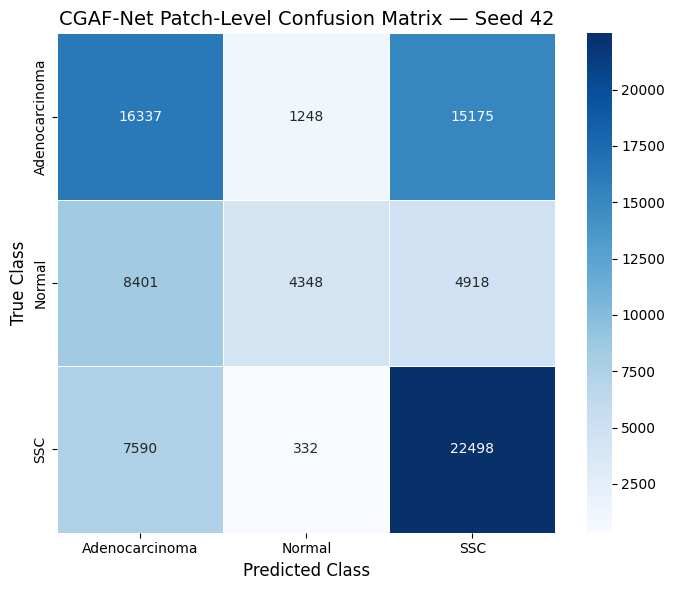

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seed 42 confusion matrix
cm = patch_confusion_matrices[42]

class_names = [
    "Adenocarcinoma",
    "Normal",
    "SSC"
]

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    cbar=True
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title(
    "CGAF-Net Patch-Level Confusion Matrix — Seed 42",
    fontsize=14
)

plt.tight_layout()
plt.show()


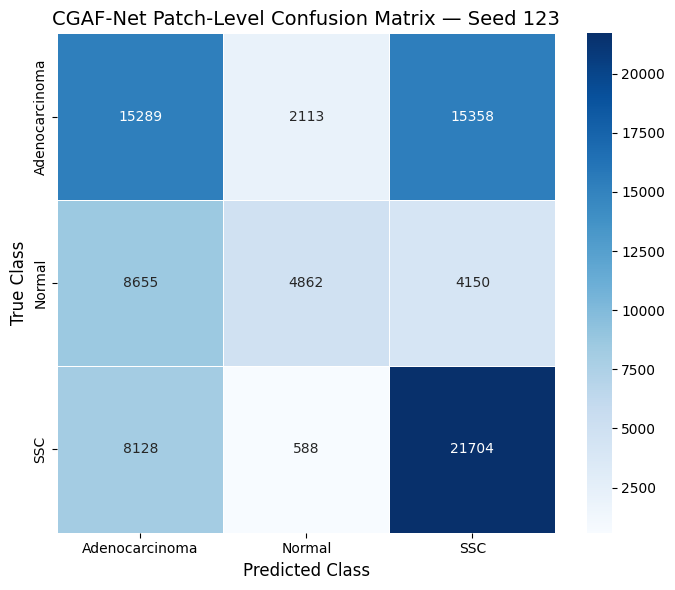

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seed 42 confusion matrix
cm = patch_confusion_matrices[123]

class_names = [
    "Adenocarcinoma",
    "Normal",
    "SSC"
]

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    cbar=True
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title(
    "CGAF-Net Patch-Level Confusion Matrix — Seed 123",
    fontsize=14
)

plt.tight_layout()
plt.show()

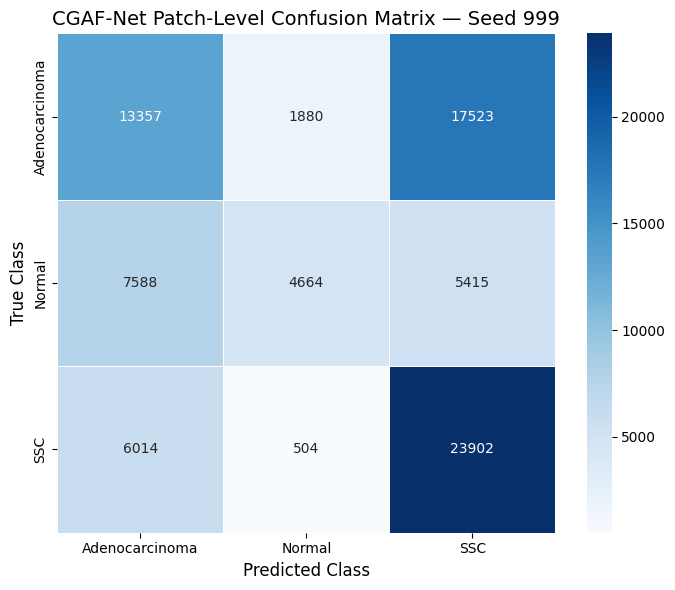

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seed 42 confusion matrix
cm = patch_confusion_matrices[999]

class_names = [
    "Adenocarcinoma",
    "Normal",
    "SSC"
]

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    cbar=True
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title(
    "CGAF-Net Patch-Level Confusion Matrix — Seed 999",
    fontsize=14
)

plt.tight_layout()
plt.show()

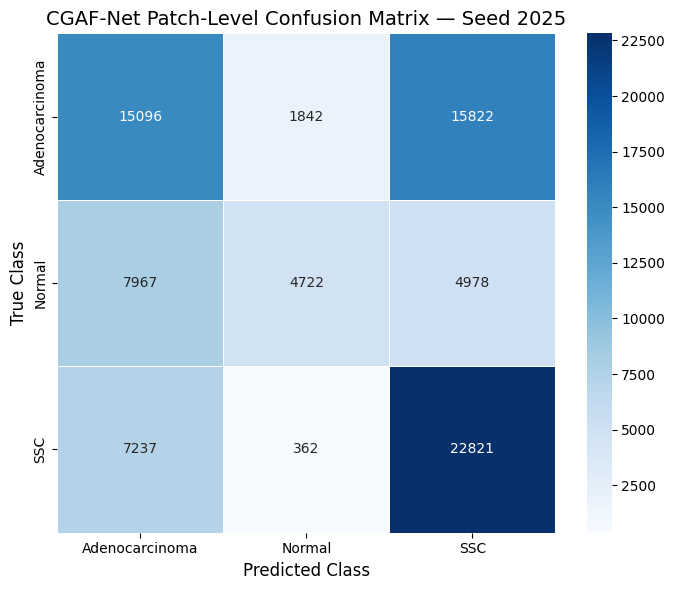

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seed 42 confusion matrix
cm = patch_confusion_matrices[2025]

class_names = [
    "Adenocarcinoma",
    "Normal",
    "SSC"
]

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    cbar=True
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title(
    "CGAF-Net Patch-Level Confusion Matrix — Seed 2025",
    fontsize=14
)

plt.tight_layout()
plt.show()

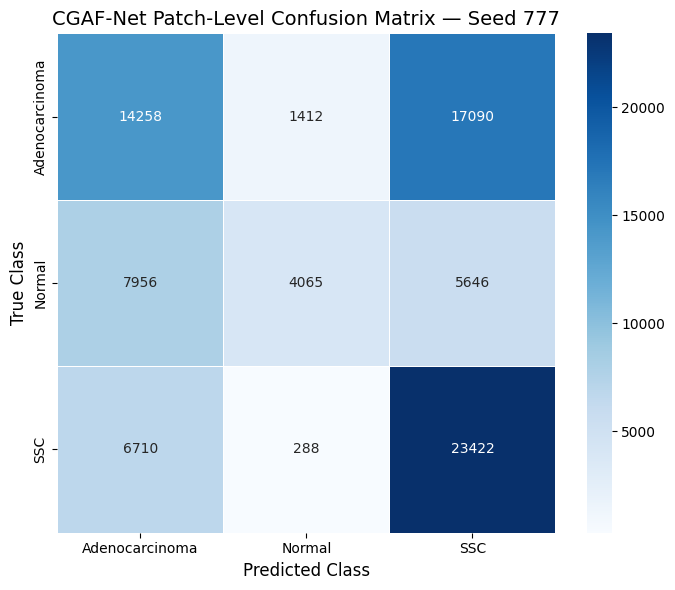

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seed 42 confusion matrix
cm = patch_confusion_matrices[777]

class_names = [
    "Adenocarcinoma",
    "Normal",
    "SSC"
]

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    cbar=True
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title(
    "CGAF-Net Patch-Level Confusion Matrix — Seed 777",
    fontsize=14
)

plt.tight_layout()
plt.show()